# HELIOS Context Import/Export Test

This notebook demonstrates how to creating a simulation context, saving it to a JSON file, and reloading it.

d:\HELIOS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Helios version: 0.1.0
Original Configuration:


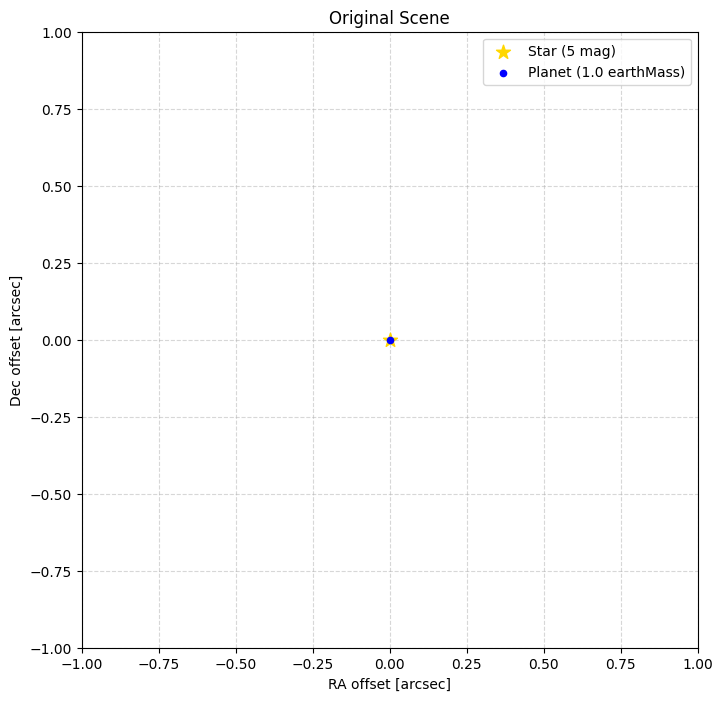

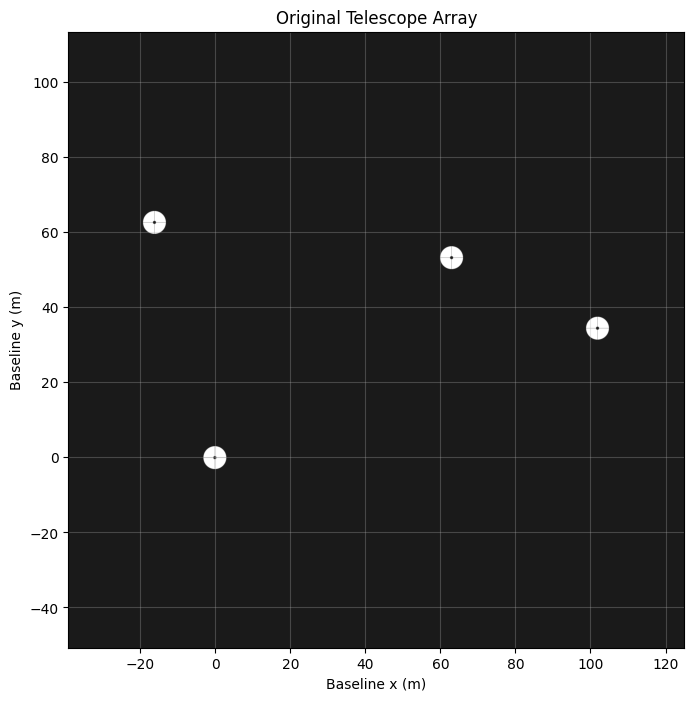


Context saved to ../generated/examples/context_demo.json


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
import helios

print(f"Helios version: {helios.__version__ if hasattr(helios, '__version__') else 'dev'}")

# 1. Create Context
ctx = helios.Context()

# 2. Add Scene
scene = helios.Scene(name="Test System", distance=10*u.pc)
scene.add(helios.Star(name="Sun", temperature=5778*u.K, magnitude=5))
scene.add(helios.Planet(name="Earth", mass=1*u.M_earth, separation=1*u.au, angle=45))
ctx.add_layer(scene)

# 3. Add Atmosphere
atm = helios.Atmosphere(rms=100*u.nm, wind_speed=10*u.m/u.s, seed=123)
ctx.add_layer(atm)

# 4. Add Telescope
ctx.add_layer(helios.TelescopeArray.vlti(uts=True))

# 5. Add Camera
ctx.add_layer(helios.Camera(pixels=(256, 256), integration_time=0.1*u.s))

# 6. Plot Original Config
print("Original Configuration:")
try:
    # Attempting to plot scene geometry if supported
    if hasattr(scene, 'plot'):
        scene.plot()
        plt.title("Original Scene")
        plt.show()
except Exception as e:
    print(f"Could not plot scene: {e}")

try:
    # Plot telescope array
    if hasattr(ctx.layers[2], 'plot_array'):
        ctx.layers[2].plot_array()
        plt.title("Original Telescope Array")
        plt.show()
except Exception as e:
    print(f"Could not plot telescope: {e}")

# 7. Save
filename = "../generated/examples/context_demo.json"
ctx.save(filename)
print(f"\nContext saved to {filename}")

In [2]:
# 1. Load Context
print(f"Loading context from {filename}...")
ctx_loaded = helios.Context.load(filename)
print("Context loaded successfully!")

# 2. Plot Loaded Config to Verify
print("\nLoaded Configuration:")

# Verify Scene
loaded_scene = next((l for l in ctx_loaded.layers if isinstance(l, helios.Scene)), None)
if loaded_scene:
    try:
        loaded_scene.plot()
        plt.title("Loaded Scene")
        plt.show()
    except Exception as e: print(e)

# Verify Telescope
loaded_tel = next((l for l in ctx_loaded.layers if isinstance(l, helios.TelescopeArray)), None)
if loaded_tel:
    try:
        loaded_tel.plot_array()
        plt.title("Loaded Telescope Array")
        plt.show()
    except Exception as e: print(e)

# Verify Atmosphere Parameter
loaded_atm = next((l for l in ctx_loaded.layers if isinstance(l, helios.Atmosphere)), None)
if loaded_atm:
    print(f"Loaded Atmosphere RMS: {loaded_atm.rms} m")
    print(f"Loaded Wind Velocity: {loaded_atm.wind_velocity}")

Loading context from ../generated/examples/context_demo.json...


NameError: name 'ctx' is not defined